In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import spikeinterface.full as si
from spikeinterface.sortingcomponents.motion import estimate_motion, interpolate_motion
from spikeinterface.widgets import plot_motion, plot_traces
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets

from spikeinterface.sortingcomponents.peak_detection import detect_peaks
from spikeinterface.sortingcomponents.peak_selection import select_peaks
from spikeinterface.sortingcomponents.peak_localization import localize_peaks
from spikeinterface.sortingcomponents.motion import estimate_motion, interpolate_motion

from scipy.signal import welch
# %matplotlib widget



In [11]:
# load the data

base_folder = Path(r'/Volumes/s2/MSIT/NPIX_MSIT_04/2025-09-18_10-15-29_NPIX_MSIT_04')
np_data = base_folder / 'Record Node 123/experiment1/recording1/'

mmap = np.memmap(np_data / 'continuous'/ 'OneBox-122.ProbeA-AP' / 'continuous.dat', dtype='int16', mode='r')
mmap.shape


(21409500672,)

In [12]:
# Load in open ephys
# Open Ephys writes a metadata file at each spot.
# The strema name has #, left of it is the node name, right of it is the stream name.

raw_rec_AP = si.read_openephys(np_data,stream_name = 'Record Node 123#OneBox-122.ProbeA-AP') #.read_spikeglx(np_data_drift)
print(raw_rec_AP)

raw_rec_LFP = si.read_openephys(np_data,stream_name = 'Record Node 123#OneBox-122.ProbeA-LFP') #.read_spikeglx(np_data_drift)
print(raw_rec_LFP)

OpenEphysBinaryRecordingExtractor: 384 channels - 30.0kHz - 1 segments - 55,753,908 samples 
                                   1,858.46s (30.97 minutes) - int16 dtype - 39.88 GiB
OpenEphysBinaryRecordingExtractor: 384 channels - 2500.0Hz - 1 segments - 4,646,159 samples 
                                   1,858.46s (30.97 minutes) - int16 dtype - 3.32 GiB


In [13]:
## spikeinterface was unhappy with 2ms margin since it may include artifacts. Changed to 20ms
AP_high = si.bandpass_filter(raw_rec_AP, freq_min=300, freq_max=3000, margin_ms=20)

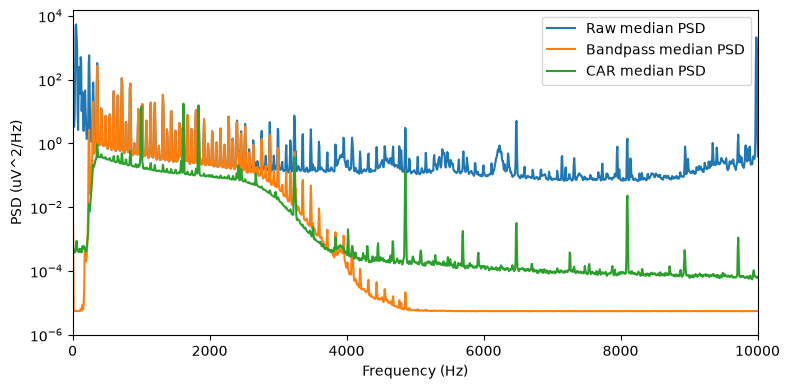

In [14]:
# we can't common average reference yet without phase correcting 
# as per the Overview markdown, the NPIX probe has too many channels to analog-to-digital convert each individually
# so channels are multiplexed (12 per probe on NPIX 1.0), which means the signal from each channel arrives one after the other..
AP_phasecorrected = si.phase_shift(recording=AP_high)  # phase correct the recording

AP_CAR = si.common_reference(recording=AP_phasecorrected) # subtract the median


# Then filter specific artifcats..?

fs = AP_CAR.get_sampling_frequency() # returns sampling frequency
n_frames = int(10 * fs) # converts 10 sec into a sample count
traces = AP_CAR.get_traces(start_frame=0, end_frame=n_frames) # shape: (time, channels)


f_raw, px_raw= welch(raw_rec_AP.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)
f_high, px_high= welch(AP_high.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)
f_CAR, px_CAR= welch(AP_CAR.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)


median_raw = np.median(px_raw, axis=1)
median_high = np.median(px_high, axis=1)
median_car = np.median(px_CAR, axis=1)

plt.figure(figsize=(8, 4))
plt.semilogy(f_raw, median_raw, label="Raw median PSD")
plt.semilogy(f_high, median_high, label="Bandpass median PSD")
plt.semilogy(f_CAR, median_car, label="CAR median PSD")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (uV^2/Hz)")
plt.xlim(0, 10000)  # adjust for AP/LFP context
plt.legend()
plt.tight_layout()
plt.show()

Detected notch freqs (Hz): [ 241.7   300.29  358.89  417.48  483.4   541.99  600.59  659.18  717.77
  776.37  842.29  959.47 1018.07 1076.66 1142.58 1201.17 1318.36 1376.95
 1442.87 1501.46 1560.06 1618.65 1677.25 1735.84 1801.76 1838.38 1918.95
 1977.54 2036.13 2102.05 2160.64 2219.24 2277.83 2336.43 2402.34 2460.94
 2519.53 2578.12 2636.72 2761.23 2878.42 2995.61 3120.12 3178.71 3237.3
 3361.82 3479.   3596.19 3837.89 3955.08 4079.59]


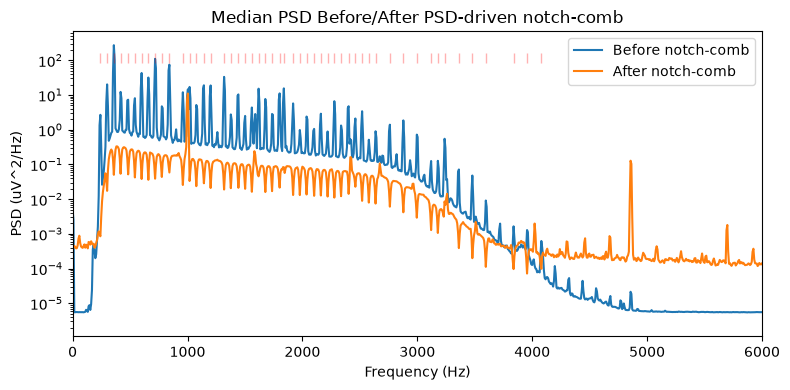

In [15]:
# Build and apply a PSD-driven notch-comb filter from AP_CAR
# Requires: AP_CAR already defined
from scipy.signal import welch, find_peaks, iirnotch, tf2sos, sosfiltfilt

f=f_high
median_psd = median_high #np.median(pxx, axis=1)
log_psd = 10 * np.log10(median_psd + 1e-20)

# 3) Detect narrow spectral spikes
freq_res = f[1] - f[0]
peaks, props = find_peaks(
    log_psd,
    prominence=6.0,                          # tune 3-10 dB
    distance=max(1, int(40 / freq_res)),     # >=40 Hz separation
)
peak_freqs = f[peaks]
peak_freqs = peak_freqs[(peak_freqs >= 50) & (peak_freqs <= 6000)]

print("Detected notch freqs (Hz):", np.round(peak_freqs, 2))

# 4) Create notch bank (comb-like if harmonically spaced)

notch_bw = 10 ## this is what was Q


sos_bank = []
for f0 in peak_freqs:
    if 0 < f0 < fs / 2:
        b, a = iirnotch(w0=f0, Q=f0/notch_bw, fs=fs) ## edited to have variable bandwidth based on frequency
        sos_bank.append(tf2sos(b, a))

tr = AP_CAR.get_traces(start_frame=0, end_frame=n_frames)  # (time, channels)

if sos_bank:
    sos = np.vstack(sos_bank)
    tr_clean = sosfiltfilt(sos, tr, axis=0)
else:
    tr_clean = tr.copy()


# 5) Compare before/after median PSD
f2, pxx2 = welch(
    tr_clean,
    fs=fs,
    nperseg=4096,
    noverlap=2048,
    detrend="constant",
    scaling="density",
    axis=0,
)
median_psd_clean = np.median(pxx2, axis=1)

plt.figure(figsize=(8, 4))
plt.semilogy(f, median_psd, label="Before notch-comb")
plt.semilogy(f2, median_psd_clean, label="After notch-comb")
if len(peak_freqs) > 0:
    y_top = np.nanmax(median_psd)
    plt.vlines(peak_freqs, y_top * 0.3, y_top * 0.6, colors="r", alpha=0.3, linewidth=1)

plt.xlim(0, 6000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (uV^2/Hz)")
plt.title("Median PSD Before/After PSD-driven notch-comb")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
## MOTION CORRECTION

# Prepare the LFP stream. Already made raw_rec_LFP in cell 9

lfp_filtered = si.bandpass_filter(
    recording=raw_rec_LFP,
    freq_min=0.5,               # keep very slow signal
    freq_max=250,
    margin_ms=10000.,            # 10 s of extra context per chunk. A 0.5 Hz filter has a 2 s period, so it needs several periods to settle/for the filter to be able to read it
    filter_order=3,
    dtype="float32",            # keep decimals 
    add_reflect_padding=True,   # at chunk edges, add reflected padding instead of zeros, so that DREDge doesn't read the edges as a big motion

    ignore_low_freq_error=True, # 0.5 Hz against 2500 Hz is an extreme ratio
)



/Users/bhw-mac/Desktop/PROJECTS/npix-bhw/neuro-env/lib/python3.14/site-packages/spikeinterface/preprocessing/filter.py:122: UserWarning: The margin size (25000 samples) is more than 20% of the global chunk size 2500 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


In [17]:
# delete earlier vars to free up memory
del traces, px_raw, px_high, px_CAR, tr, tr_clean, pxx2
import gc; gc.collect()

#Check that server drive is loaded 
print(raw_rec_LFP.get_total_duration() / 60, 'min')






30.97439333333333 min


In [18]:
lfprec_deriv = si.directional_derivative(lfp_filtered, order=2, edge_order=1) #this takes the second derivative along depth, telling us how sharply LFP changes with depth

lfprec_deriv = si.average_across_direction(lfprec_deriv) # NP1.0 sit in staggered columns, so we average across the columns to make a single channel value per depth.
lfprec_deriv = si.resample(lfprec_deriv, resample_rate=250, margin_ms=1000) # resample down to 250hz so that we only keep 250 samples per second. It low pass filters first..?

motion_folder = base_folder / 'motion_DREDGE_LFP/'
motion_nonrigid = estimate_motion(lfprec_deriv, method='dredge_lfp', rigid=False, progress_bar=True)
motion_nonrigid.save(motion_folder)
motion_nonrigid


Online chunks [10.0s each]:   0%|          | 0/185 [00:00<?, ?it/s]

Motion non-rigid - 18 spatial bins - interval 0.0040000000000048885s - 1 segments

already saved: /Volumes/s2/MSIT/NPIX_MSIT_04/2025-09-18_10-15-29_NPIX_MSIT_04/motion_DREDGE_LFP


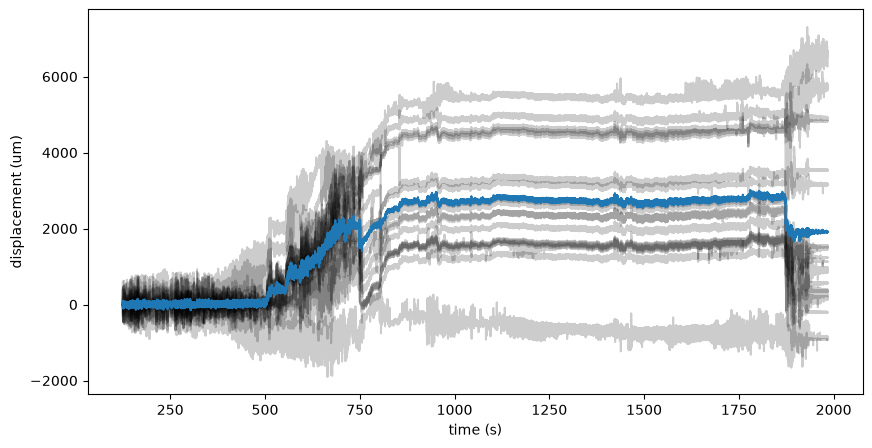

drift range:  -1906.5 to 7305.3 um
peak-to-peak: 9211.8 um


In [ ]:
if motion_folder.exists():
    print(f'already saved: {motion_folder}')
else:
    motion_nonrigid.save(motion_folder)
    print(f'saved: {motion_folder}')


# plotting the motion
fig, ax = plt.subplots(figsize=(10, 5))
si.plot_motion(motion_nonrigid, mode='line', ax=ax)
ax.set_xlabel('time (s)')
ax.set_ylabel('displacement (um)')
plt.show()

d = motion_nonrigid.displacement[0]
print(f'drift range:  {d.min():.1f} to {d.max():.1f} um')
print(f'peak-to-peak: {d.max() - d.min():.1f} um')

# gray is one line per depth window, blue is the mean 

Text(0, 0.5, 'LFP (uV)')

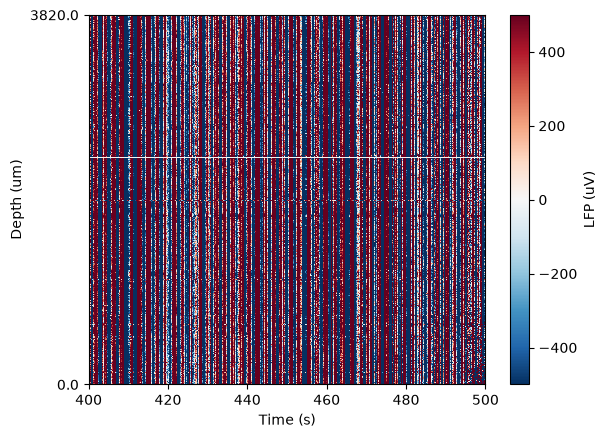

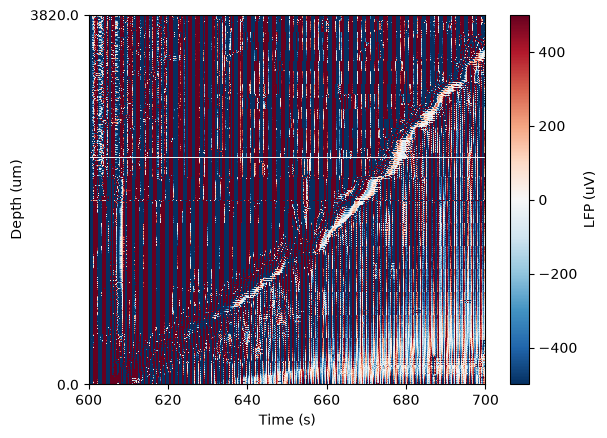

In [26]:
## there is lots of motion before ~750s, let's investigate..
# was that before the probe was done being inserted?
w = si.plot_traces(lfp_filtered, time_range=(400, 500), mode='map', clim=(-500, 500))
w.ax.set_xlabel('Time (s)')
w.ax.set_ylabel('Depth (um)')
w.figure.axes[-1].set_ylabel('LFP (uV)')

w = si.plot_traces(lfp_filtered, time_range=(600, 700), mode='map', clim=(-500, 500))
w.ax.set_xlabel('Time (s)')
w.ax.set_ylabel('Depth (um)')
w.figure.axes[-1].set_ylabel('LFP (uV)')


In [ ]:
ev = si.read_openephys_event(np_data)
print(ev.channel_ids)

times = ev.get_events(channel_id=ev.channel_ids[0]) # this shows the messages from npix
print(times[:5], times[-1])

['Messages' 'OneBox ADC Digital Lines' 'Neuropixels PXI Sync'
 'Neuropixels PXI Sync']
[( 143.1982, nan, 'mounting on lexell at start of recording')
 (1026.7086, nan, 'implanted at 8ish ') (1121.2782, nan, 'task at 16.28')
 (1121.4182, nan, 'task at 16.28') (1867.3142, nan, 'task at 29.00')] (1940.4696, nan, 'pumps on at 30.15')


In [30]:
#Implanted looks to be around 1026 seconds. Well start DREDGing from there!

lfp_task = raw_rec_LFP.time_slice(start_time=1121.0, end_time=None)

lfp_task_filt = si.bandpass_filter(
    recording=lfp_task,
    freq_min=0.5, freq_max=250, margin_ms=10000.,
    filter_order=3, dtype="float32",
    add_reflect_padding=True, ignore_low_freq_error=True,
)

lfp_task_deriv = si.directional_derivative(lfp_task_filt, order=2, edge_order=1)
lfp_task_deriv = si.average_across_direction(lfp_task_deriv)
lfp_task_deriv = si.resample(lfp_task_deriv, resample_rate=250, margin_ms=1000)

motion_task = estimate_motion(lfp_task_deriv, method='dredge_lfp', rigid=False, progress_bar=True)



Online chunks [10.0s each]:   0%|          | 0/86 [00:00<?, ?it/s]

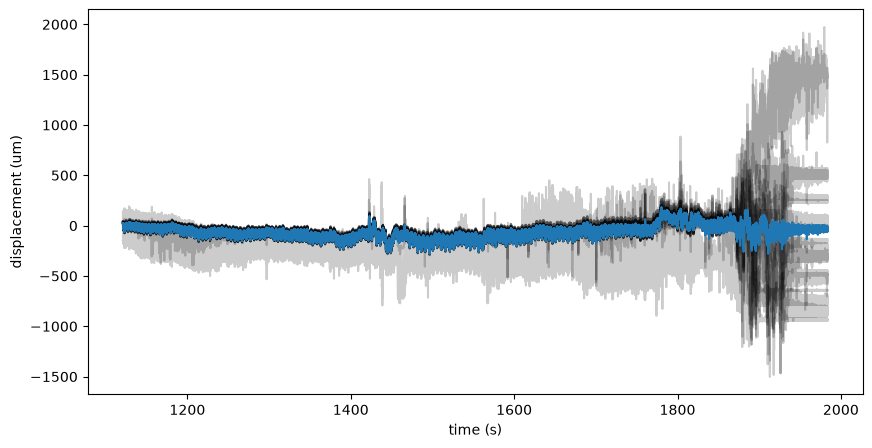

peak-to-peak: 3477.5 um


In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
si.plot_motion(motion_task, mode='line', ax=ax)
ax.set_xlabel('time (s)'); ax.set_ylabel('displacement (um)')
plt.show()

d = motion_task.displacement[0]
print(f'peak-to-peak: {d.max() - d.min():.1f} um')